In [1]:
from qualibrate import QualibrationNode
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

2026-03-17 15:39:01,739 - qm - INFO     - Starting session: d618aa97-4fdb-42f5-88fc-ec90da83f953


In [2]:
node = QualibrationNode(name=f"Gate_Set_Tomography_data_processing")

2026-03-17 15:39:05,204 - qualibrate - INFO - Creating node Gate_Set_Tomography_data_processing


In [3]:
from pathlib import Path
data_path = Path("data/GST_gate_error").resolve()

In [ ]:
gate_error_idx = 621

alpha_list = np.arange(0.9, 1.61, 0.01)
alpha_list = [round(a, 2) for a in alpha_list]

max[i]_circuit_length = [
    2**i for i in range(5)
    ]

ds = node.load_from_id(gate_error_idx, base_path = data_path).results
results = ds["results"]

In [9]:
conditions = ["TP", "CPTP", "Ideal"]
state_fidelity = np.array([results[con]["rho0"]["fidelity"] for con in conditions])
measure_fidelity = np.array([results[con]["meas_op"]["0"]["fidelity"] for con in conditions])
identity_fidelity = np.array([results[con]["gate_op"]["I"]["fidelity"] for con in conditions])
x90_fidelity = np.array([results[con]["gate_op"]["x90"]["fidelity"] for con in conditions])
y90_fidelity = np.array([results[con]["gate_op"]["y90"]["fidelity"] for con in conditions])
identity_robust = np.array([results[con]["gate_op"]["I"]["robustness"] for con in conditions])
x90_robust = np.array([results[con]["gate_op"]["x90"]["robustness"] for con in conditions])
y90_robust = np.array([results[con]["gate_op"]["y90"]["robustness"] for con in conditions])

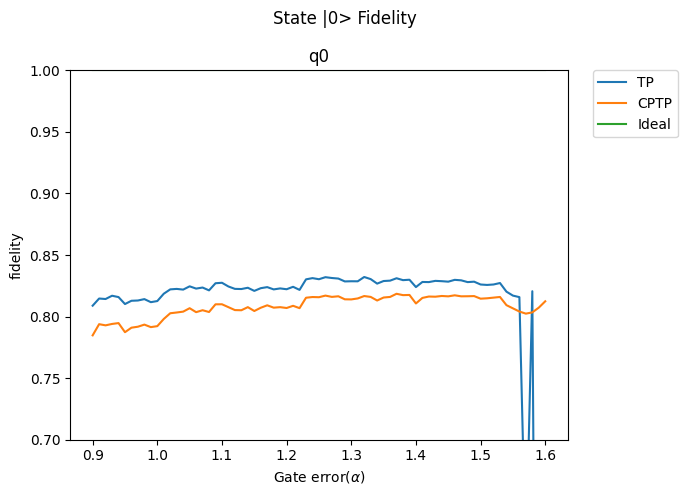

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(alpha_list, state_fidelity.T, label = ["TP", "CPTP", "Ideal"])
ax.set_ylim(0.7, 1)
ax.set_ylabel("fidelity")
ax.set_xlabel(r"Gate error($\alpha$)")
ax.set_title("q0")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.suptitle("State |0> Fidelity")
plt.tight_layout()
plt.show()

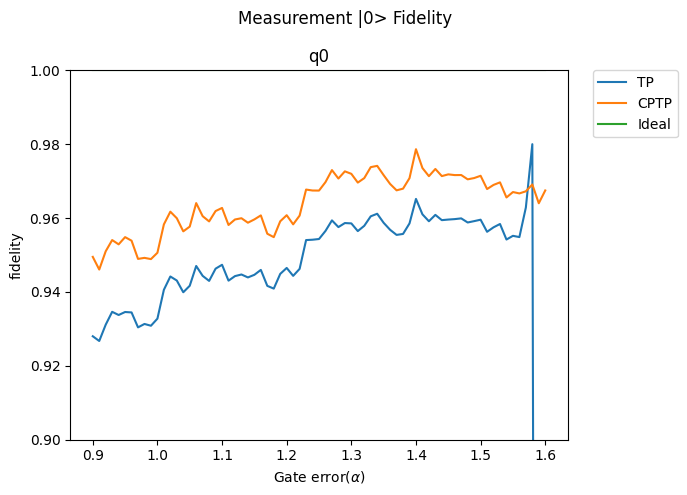

In [11]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(alpha_list, measure_fidelity.T, label = ["TP", "CPTP", "Ideal"])
ax.set_ylim(0.9, 1)
ax.set_ylabel("fidelity")
ax.set_xlabel(r"Gate error($\alpha$)")
ax.set_title("q0")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.suptitle("Measurement |0> Fidelity")
plt.tight_layout()
plt.show()

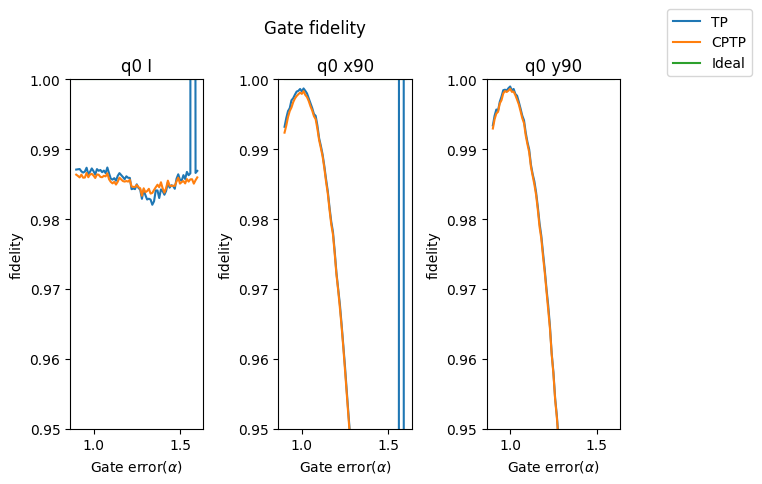

In [17]:
fig, ax = plt.subplots(1, 3)
gate_labels = ["I", "x90", "y90"]
fidelity = [identity_fidelity, x90_fidelity, y90_fidelity]
for i in range(3):
    ax[i].plot(alpha_list, fidelity[i].T, label = ["TP", "CPTP", "Ideal"] if i == 2 else None)
    ax[i].set_ylim(0.95, 1)
    ax[i].set_ylabel("fidelity")
    ax[i].set_xlabel(r"Gate error($\alpha$)")
    ax[i].set_title(f"q0 {gate_labels[i]}")
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.suptitle("Gate fidelity")
plt.tight_layout()
plt.show()

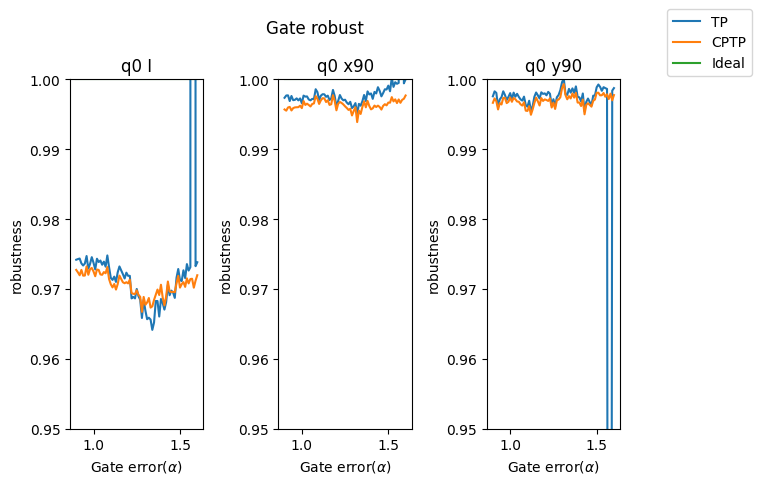

In [18]:
fig, ax = plt.subplots(1, 3)
gate_labels = ["I", "x90", "y90"]
robustness = [identity_robust, x90_robust, y90_robust]
for i in range(3):
    ax[i].plot(alpha_list, robustness[i].T, label = ["TP", "CPTP", "Ideal"] if i == 2 else None)
    ax[i].set_ylim(0.95, 1)
    ax[i].set_ylabel("robustness")
    ax[i].set_xlabel(r"Gate error($\alpha$)")
    ax[i].set_title(f"q0 {gate_labels[i]}")
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.suptitle("Gate robust")
plt.tight_layout()
plt.show()